In [8]:
import re
import os
from pathlib import Path
from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import SimpleITK as sitk

os.chdir("/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/3resampledNiftiNyulReady/MR")

def parse_mr_filename(filename: str):
    """
    Extract region, center, and year from filenames like:
    - AB_1ABC118_MR.nii.gz
    - brain_1BA345_MR.nii.gz

    Rules:
    - Extract the part between the first and second underscore.
    - center = last letter of that segment
    - region = all letters before the center
    - year = 2023 if region is 'B' or 'P', otherwise 2025
    """
    # Get substring between first and second underscore
    match = re.search(r'^[^_]+_([^_]+)_', filename)
    if not match:
        raise ValueError(f"Filename format not recognized: {filename}")

    middle = match.group(1)

    # Extract letters only
    letters = re.findall(r'[A-Za-z]', middle)
    if not letters:
        raise ValueError(f"No letters found in middle segment of {filename}")

    center = letters[-1]
    region = ''.join(letters[:-1])

    # Year rule
    year = "2023" if region in ("B", "P") else "2025"

    center_year = center + "_" + year

    return region, center_year


def find_global_min_max(paths):
    """
    First step: find global min and max voxel values across all volumes.
    """
    global_min = None
    global_max = None

    for p in tqdm(paths):
        img = sitk.ReadImage(str(p))
        arr = sitk.GetArrayFromImage(img).astype(float)
        vmin = float(np.min(arr))
        vmax = float(np.max(arr))

        if global_min is None or vmin < global_min:
            global_min = vmin
        if global_max is None or vmax > global_max:
            global_max = vmax

    return global_min, global_max

def build_cdf_table(paths, min, max, n_points=200):
    """
    Second step: build a table with 200 columns going from global min to global max,
    each column containing the CDF value (percent of voxels <= threshold intensity)
    for each volume.

    Additional columns added:
    - min_value (float)
    - max_value (float)
    - nx, ny, nz (voxel dimensions)

    Returns
    -------
    table : np.ndarray (structured)
        One row per volume.
    thresholds : np.ndarray
        Intensity thresholds (same for all volumes).
    """

    # 1) Global min & max from first pass
    global_min, global_max = min, max

    # 2) Define intensity thresholds
    thresholds = np.linspace(global_min, global_max, n_points)

    # 3) Table dtype
    meta_fields = [
        ("filename", "U32"),
        ("region", "U16"),
        ("center_year", "U8"),

        ("min_value", "f4"),
        ("max_value", "f4"),

        ("nx", "i4"),
        ("ny", "i4"),
        ("nz", "i4"),

        ("n_voxels", "i8"),
    ]

    cdf_fields = [(f"cdf_{i:03d}", "f4") for i in range(n_points)]
    dtype = np.dtype(meta_fields + cdf_fields)

    records = []

    for p in tqdm(paths):
        p = Path(p)
        img = sitk.ReadImage(str(p))

        arr = sitk.GetArrayFromImage(img).astype(np.float32)
        flat = arr.ravel()
        n_voxels = flat.size

        # Volume shape (z, y, x)
        nz, ny, nx = arr.shape

        # Per-volume min/max
        vmin = float(np.min(arr))
        vmax = float(np.max(arr))

        # CDF
        flat_sorted = np.sort(flat)
        idx = np.searchsorted(flat_sorted, thresholds, side="right")
        cdf = idx.astype(np.float64) / float(n_voxels)

        region, center_year = parse_mr_filename(p.name)

        record = (
            p.name,
            region,
            center_year,

            vmin,
            vmax,

            nx,
            ny,
            nz,

            int(n_voxels),

            *cdf.astype(np.float32)
        )

        records.append(record)

    table = np.array(records, dtype=dtype)
    return table, thresholds

def reconstruct_global_histogram_from_table(table, thresholds, group_col=None):
    """
    Reconstruct histogram(s) of voxel values across volumes using only the CDF
    table and the thresholds.

    Parameters
    ----------
    table : np.ndarray (structured)
        Must contain:
          - 'n_voxels' column (per volume)
          - 'cdf_*' columns: CDF values at each threshold
        Optionally:
          - group_col: column whose values define groups of volumes
    thresholds : np.ndarray
        Thresholds / bin edges used for the CDFs.
    group_col : str or None, optional
        Name of a column in `table` used to group volumes.
        If None, computes a single global histogram (original behavior).
        If not None, returns one histogram per unique value in table[group_col].

    Returns
    -------
    hist_counts : np.ndarray
        - If group_col is None: shape (n_bins,)
        - If group_col is not None: shape (n_groups, n_bins)
    bin_edges : np.ndarray
        Same as thresholds, shape (n_bins+1,)
    groups : np.ndarray, optional
        Returned only if group_col is not None. Unique group labels in the
        same order as the first axis of hist_counts.
    """
    # Extract CDF columns (ensure correct order)
    cdf_field_names = sorted(
        [name for name in table.dtype.names if name.startswith("cdf_")]
    )
    # Shape: (n_volumes, n_points)
    cdfs = np.vstack([table[name] for name in cdf_field_names]).T

    n_vols, n_points = cdfs.shape
    assert n_points == len(thresholds), "Thresholds length must match CDF points."

    # Total voxels per volume
    n_voxels_per_vol = table["n_voxels"].astype(float)

    bin_edges = np.asarray(thresholds, dtype=float)

    # --- No grouping: original global aggregation ---
    if group_col is None:
        total_voxels = float(np.sum(n_voxels_per_vol))
        weights = n_voxels_per_vol / total_voxels  # sum to 1

        # Weighted global CDF
        global_cdf = np.sum(weights[:, None] * cdfs, axis=0)

        # Differences -> histogram probabilities
        hist_probs = np.diff(global_cdf)
        hist_probs = np.clip(hist_probs, 0.0, None)
        if hist_probs.sum() > 0:
            hist_probs /= hist_probs.sum()

        hist_counts = hist_probs * total_voxels
        return hist_counts, bin_edges

    # --- With grouping ---
    group_values = table[group_col]
    unique_groups = np.unique(group_values)

    all_hist_counts = []

    for g in unique_groups:
        mask = (group_values == g)
        if not np.any(mask):
            # Just in case, skip empty group (shouldn't happen with np.unique)
            continue

        # Subset of volumes in this group
        cdfs_g = cdfs[mask]                       # (n_vols_g, n_points)
        n_voxels_g = n_voxels_per_vol[mask]       # (n_vols_g,)

        total_voxels_g = float(np.sum(n_voxels_g))
        if total_voxels_g == 0:
            # Avoid division by zero; create zero histogram
            all_hist_counts.append(np.zeros(len(thresholds) - 1, dtype=float))
            continue

        weights_g = n_voxels_g / total_voxels_g   # sum to 1 within group

        # Weighted CDF for this group
        global_cdf_g = np.sum(weights_g[:, None] * cdfs_g, axis=0)

        # Differences -> histogram probabilities
        hist_probs_g = np.diff(global_cdf_g)
        hist_probs_g = np.clip(hist_probs_g, 0.0, None)
        if hist_probs_g.sum() > 0:
            hist_probs_g /= hist_probs_g.sum()

        # Convert to counts for this group's total voxels
        hist_counts_g = hist_probs_g * total_voxels_g
        all_hist_counts.append(hist_counts_g)

    hist_counts = np.vstack(all_hist_counts)  # shape (n_groups, n_bins)
    return hist_counts, bin_edges, unique_groups


def plot_density_line(
    hist_counts,
    bin_edges,
    title="Global Voxel Intensity Density",
    remove_mode=False,
    labels=None,
    plot_counts=True,
):
    """
    Plot one or more histograms as continuous densities (line plot).

    Parameters
    ----------
    hist_counts : np.ndarray
        - shape (n_bins,) for a single histogram
        - shape (n_groups, n_bins) for multiple histograms
    bin_edges : np.ndarray
        Bin edges, shape (n_bins+1,).
    title : str
        Plot title.
    remove_mode : bool
        If True, sets the highest density value to 0 for each line.
    labels : list of str or None
        Labels for each line (for legend). Length must be n_groups if provided.
    """
    hist_counts = np.asarray(hist_counts, dtype=float)
    bin_edges = np.asarray(bin_edges, dtype=float)

    if hist_counts.ndim == 1:
        hist_counts = hist_counts[None, :]  # shape -> (1, n_bins)

    n_groups, n_bins = hist_counts.shape

    # Use bin centers for plotting
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    bin_widths = np.diff(bin_edges)

    if labels is None:
        labels = [f"Group {i}" for i in range(n_groups)]

    plt.figure(figsize=(10, 5))

    for i in range(n_groups):
        counts = hist_counts[i]
        total_count = counts.sum()

        if total_count == 0:
            # Skip empty histogram
            continue

        densities = counts / (total_count * bin_widths)

        if remove_mode:
            max_idx = np.argmax(densities)
            counts[max_idx] = np.nan
            densities[max_idx] = np.nan

        if plot_counts:
            plt.plot(bin_centers, counts, linewidth=2, label=str(labels[i]))
        else:
            plt.plot(bin_centers, densities, linewidth=2, label=str(labels[i]))

    final_title = title
    if remove_mode:
        final_title += " (mode set to 0 for visibility)"

    if plot_counts:
        final_title = final_title.replace("Density", "Count")

    plt.xlabel("Intensity")
    plt.ylabel("Value Count" if plot_counts else "Density")
    plt.title(final_title)
    if n_groups > 1:
        plt.legend()
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

def percentile_table_from_hist(
    hist_counts,
    bin_edges,
    labels,
    percentiles=(99, 95),
):
    """
    Compute percentiles from histogram counts for each row.

    Parameters
    ----------
    hist_counts : np.ndarray
        - shape (n_bins,) for a single histogram
        - shape (n_rows, n_bins) for multiple histograms
    bin_edges : np.ndarray
        Bin edges, shape (n_bins + 1,).
    percentiles : iterable of float
        Percentiles to compute, in [0, 100]. Default: (99, 95).

    Returns
    -------
    table : np.ndarray (structured)
        Structured array with one row per histogram and one column per percentile.
        Column names are "pXX" where XX is the percentile integer, e.g. "p99".
    """
    hist_counts = np.asarray(hist_counts, dtype=float)
    bin_edges = np.asarray(bin_edges, dtype=float)

    # Ensure 2D: (n_rows, n_bins)
    if hist_counts.ndim == 1:
        hist_counts = hist_counts[None, :]

    n_rows, n_bins = hist_counts.shape
    assert bin_edges.shape[0] == n_bins + 1, "bin_edges must be length n_bins + 1."

    # Use bin centers as representative intensity values for interpolation
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

    perc = np.asarray(percentiles, dtype=float)
    probs = perc / 100.0  # convert to [0,1]

    # Build a structured dtype: ('p99','f8'), ('p98','f8'), ...
    dtype = [(f"p{int(p)}", "f8") for p in percentiles]
    out = np.zeros(n_rows, dtype=dtype)

    for i in range(n_rows):
        counts = hist_counts[i]
        total = counts.sum()

        if total <= 0:
            # No data -> NaNs
            for name, _ in dtype:
                out[name][i] = np.nan
            continue

        pdf = counts / total
        cdf = np.cumsum(pdf)

        for p_val, q, (name, _) in zip(percentiles, probs, dtype):
            # Find first bin where CDF >= q
            idx = np.searchsorted(cdf, q)

            # Handle edges
            if idx == 0:
                xq = bin_centers[0]
            elif idx >= len(bin_centers):
                xq = bin_centers[-1]
            else:
                # Linear interpolation within the bin between bin_centers[idx-1] and bin_centers[idx]
                cdf_lo = cdf[idx - 1]
                cdf_hi = cdf[idx]
                x_lo = bin_centers[idx - 1]
                x_hi = bin_centers[idx]

                if cdf_hi == cdf_lo:
                    t = 0.0
                else:
                    t = (q - cdf_lo) / (cdf_hi - cdf_lo)

                xq = x_lo + t * (x_hi - x_lo)

            out[name][i] = xq

    df = pd.DataFrame(out)
    df.insert(0, "group", labels)

    return df


In [2]:
# find filenames per data split
split = pd.read_csv("../../splits_manifest.csv")
split["filename"] = split["example_path"].str.split("/").str[-1]
split["filename"] = split["filename"].str.split("-").str[0]
split["filename"] = split["filename"] + "_MR.nii.gz"

all_files = split["filename"].tolist()

train_files = split[split["split"]=="train"]
train_files = train_files["filename"].tolist()

test_files = split[split["split"]=="test"]
test_files = test_files["filename"].tolist()

In [ ]:
files = all_files

# Step 1: Find global min and max intensity values
min, max = find_global_min_max(files)
print(f"min={round(min, 5)}\nmax={round(max, 5)}")

# Step 2: build the CDF table
# min, max = 0, 5161
# print(f"min={round(min, 5)}\nmax={round(max, 5)}")
table, thresholds = build_cdf_table(files, min - 150, max + 150, n_points=50)

min=0
max=5161


  0%|          | 0/938 [00:00<?, ?it/s]

100%|██████████| 938/938 [08:28<00:00,  1.85it/s]


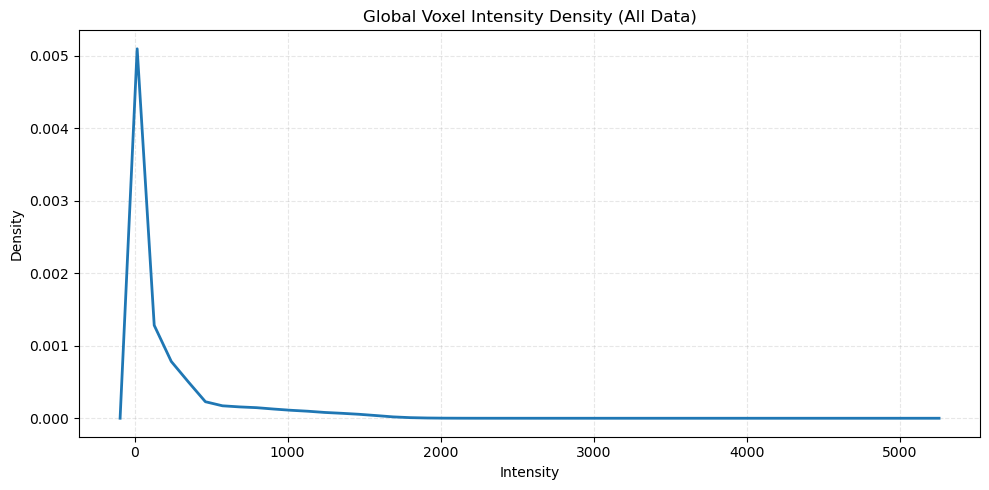

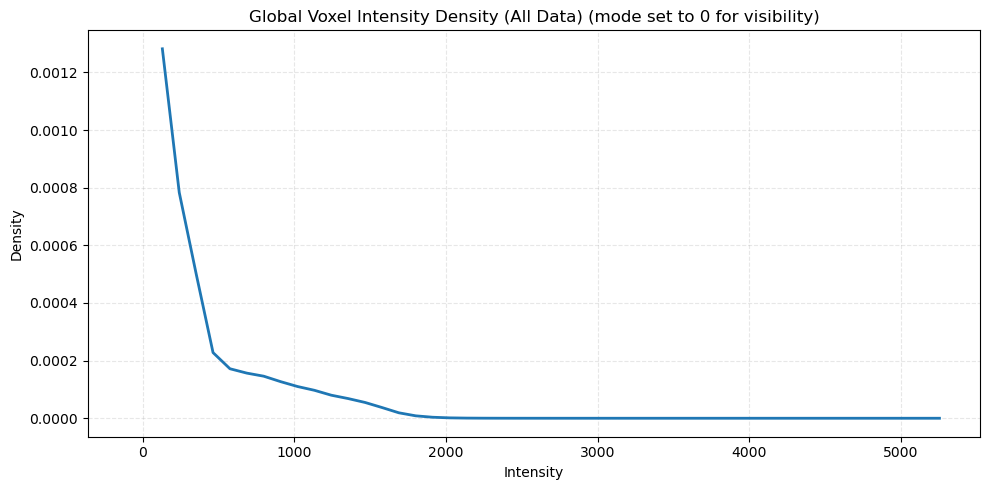

  group          p99        p95         p90
0   All  1426.713817  941.07862  583.574028


In [15]:
# Step 3: reconstruct global histogram on all data
hist_counts, bin_edges = reconstruct_global_histogram_from_table(table, thresholds, group_col=None)
percentile_table = percentile_table_from_hist(hist_counts, bin_edges, labels="All", percentiles=(99, 95, 90))

# Step 4: Plot
title="Global Voxel Intensity Density (All Data)"
plot_density_line(hist_counts, bin_edges, title=title, labels="All", remove_mode=False, plot_counts=False)
plot_density_line(hist_counts, bin_edges, title=title, labels="All", remove_mode=True, plot_counts=False)
print(percentile_table)

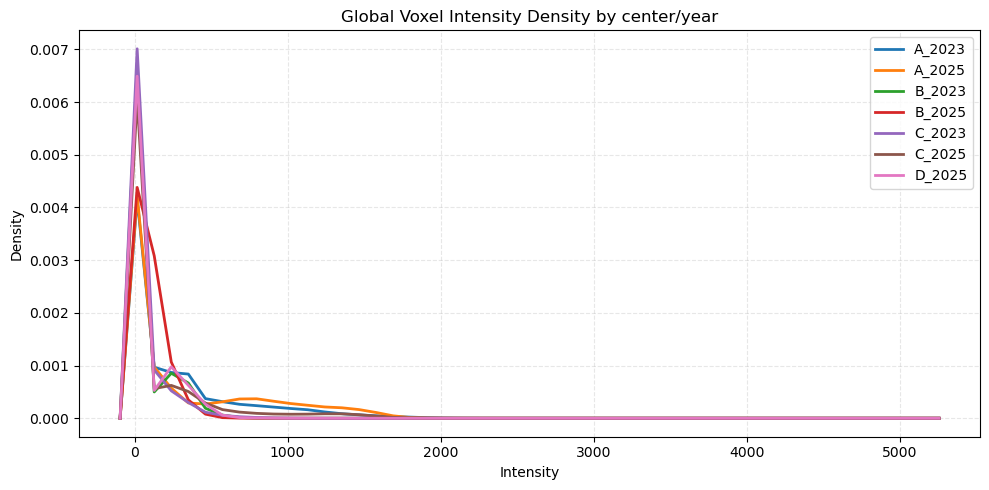

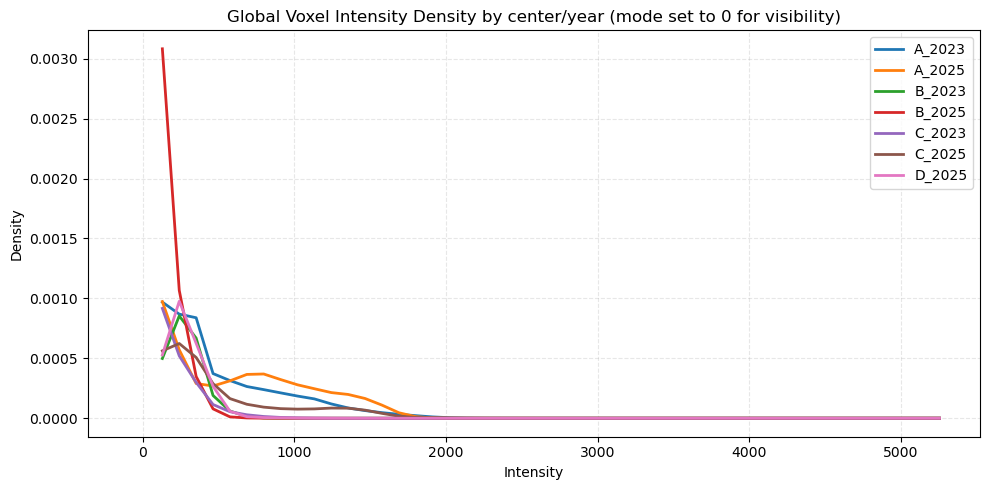

    group          p99          p95
0  A_2023  1538.822575  1090.811588
1  A_2025  1551.031330  1292.536499
2  B_2023   456.173892   321.436854
3  B_2025   356.763255   239.390132
4  C_2023   504.885324   268.183232
5  C_2025  1432.873692   925.674635
6  D_2025   461.055497   334.189892


In [ ]:
# Step 3: reconstruct global histogram by center_year
hist_counts, bin_edges, groups = reconstruct_global_histogram_from_table(table, thresholds, group_col="center_year")
percentile_table = percentile_table_from_hist(hist_counts, bin_edges, labels=groups.astype(str))

# Step 4: Plot
title="Global Voxel Intensity Density by center/year"
plot_density_line(hist_counts, bin_edges, title=title, labels=groups.astype(str), remove_mode=False, plot_counts=False)
plot_density_line(hist_counts, bin_edges, title=title, labels=groups.astype(str), remove_mode=True, plot_counts=False)
print(percentile_table)

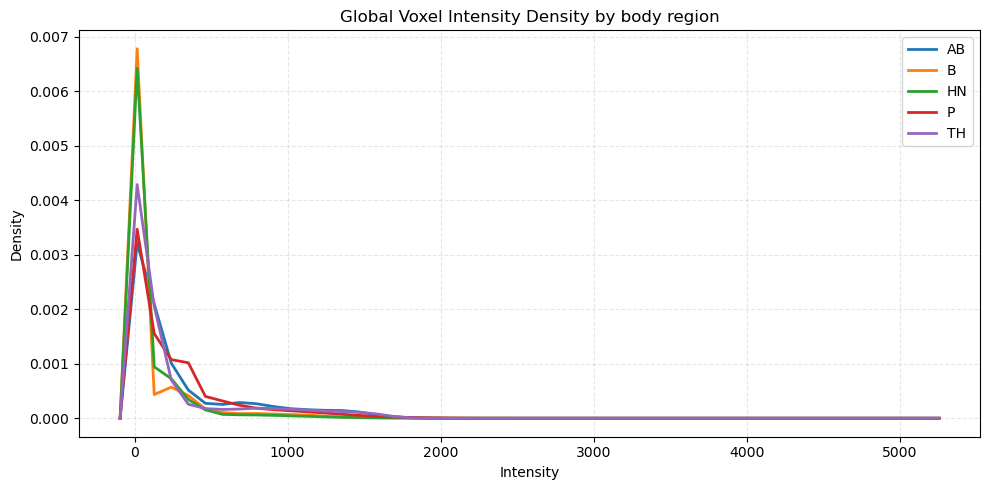

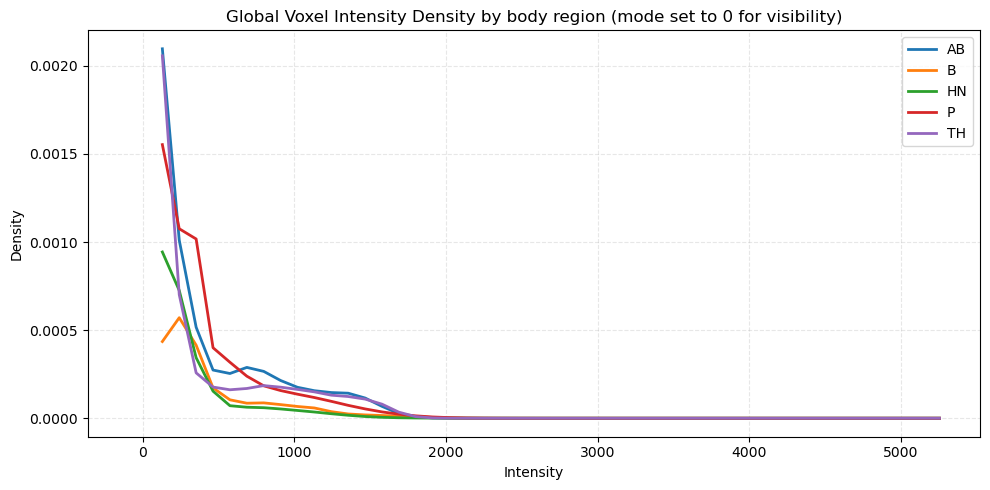

  group          p99          p95
0    AB  1493.289485  1177.883583
1     B  1234.829457   640.997725
2    HN  1050.049315   420.269426
3     P  1458.770489  1001.787236
4    TH  1515.883584  1165.629952


In [10]:
# Step 3: reconstruct global histogram by center_year
hist_counts, bin_edges, groups = reconstruct_global_histogram_from_table(table, thresholds, group_col="region")
percentile_table = percentile_table_from_hist(hist_counts, bin_edges, labels=groups.astype(str))

# Step 4: Plot
title="Global Voxel Intensity Density by body region"
plot_density_line(hist_counts, bin_edges, title=title, labels=groups.astype(str), remove_mode=False, plot_counts=False)
plot_density_line(hist_counts, bin_edges, title=title, labels=groups.astype(str), remove_mode=True, plot_counts=False)
print(percentile_table)